<a href="https://colab.research.google.com/github/uddipta-deka/Comparative-Analysis-of-CNN-Architectures-for-Brain-MRI-Classification-using-Transfer-learning/blob/main/notebooks/3_Transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Transfer Learning Model Comparison for Brain Tumor Classification

In this notebook, I am comparing multiple pretrained models (VGG16, ResNet50, EfficientNetB0) with the baseline CNN model to evaluate performance improvements.

In [2]:
import os

BASE_PATH = "/content/drive/MyDrive/Brain Tumor Classification"

TRAIN_DIR = os.path.join(BASE_PATH, "dataset", "Training")
TEST_DIR = os.path.join(BASE_PATH, "dataset", "Testing")


In [3]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator


from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
#Training Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


test_datagen = ImageDataGenerator(rescale=1./255)


train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
print("Class Indices:", train_gen.class_indices)

Class Indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


**Experiment 1: VGG16 (Classic Transfer Learning Approach)**

VGG16 is a well-known deep convolutional network. I am using it as the first transfer learning model to see how a standard architecture performs on this dataset.

Strategy: Two-Stage Training

**Stage 1 (Feature Extraction):**

Freezing the VGG16 base model and train only the custom classification layers.

**Stage 2 (Fine-Tuning):**

Unfreezing the top layers of the model and train with a low learning rate to adapt the features to MRI images.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# VGG16 base
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


base_vgg.trainable = False

# Classification head
x = base_vgg.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

#  Final model
model_vgg = Model(inputs=base_vgg.input, outputs=predictions)


model_vgg.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,02

 Total params: 14,848,068 (56.64 MB)

 Trainable params: 132,868 (519.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

**Model Design Choices**

GlobalAveragePooling2D: Used to reduce parameters and avoid overfitting compared to Flatten.

BatchNormalization: Helps stabilize training of the new layers.

Dropout (0.5): Added to reduce overfitting.

Learning Rate (1e-3): Used for faster training in Stage 1 since the base model is frozen.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Define Callbacks for Stage 1
SAVE_PATH = os.path.join(BASE_PATH, 'models')
os.makedirs(SAVE_PATH, exist_ok=True)

checkpoint_vgg_s1 = ModelCheckpoint(
    filepath=os.path.join(SAVE_PATH, 'vgg16_stage1.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# TRAINING
print("Training VGG16 Stage 1:")
history_vgg_s1 = model_vgg.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=[checkpoint_vgg_s1, early_stop, reduce_lr]
)

Training VGG16 Stage 1:
Epoch 1/15
  7/140 ━━━━━━━━━━━━━━━━━━━━ 40:39 18s/step - accuracy: 0.3034 - loss: 1.6111

KeyboardInterrupt: 

### VGG16 Stage 1: Results & Observations

**The "Stage-1" phase has successfully concluded with the following metrics:**

**Best Validation Accuracy:** 91.61%

**Final Validation Loss:** 0.2559

**Learning Rate Adjustments:** The model required one decay (Epoch 6) to stabilize.

**Analysis**

VGG16 Stage 1 has already outperformed the custom CNN baseline (86%) by 5.61%. The high validation accuracy relative to training accuracy (~90%) indicates that the Dropout(0.5) and BatchNormalization layers are effectively regularizing the model, preventing overfitting even with a large pre-trained base.

## Stage 2: Fine-Tuning using Functional Blocks
In this stage, I am performing fine-tuning of the pretrained model to further improve performance. Instead of unfreezing the entire network or using a fixed percentage of layers, I follow a functional block-based approach.

**Strategy :**

Only the final convolutional block of the pretrained model is unfrozen.

Earlier layers remain frozen to preserve low-level features such as edges and textures.

The unfrozen layers are trained with a very low learning rate (1e-5) to make small, controlled updates.

**Rationale :**

Different architectures have different depths and internal structures, so unfreezing a fixed number or percentage of layers may not be consistent across models. By targeting the last functional block, I ensure that:


High-level, task-specific features are adapted to the MRI dataset

Pretrained low-level representations are preserved

The comparison between models remains fair and meaningful

**Model-Specific Fine-Tuning**

VGG16: Unfreeze Block 5 (final convolutional block)

ResNet50: Unfreeze Stage 5 (final residual block)

EfficientNetB0: Unfreeze Block 7 (final MBConv block)

In [ ]:
from tensorflow.keras.models import load_model


# Stage 1 model
SAVE_PATH = os.path.join(BASE_PATH, 'models')
model_vgg = load_model(os.path.join(SAVE_PATH, 'vgg16_stage1.keras'))

# Unfreezinng only the Final Functional Block

# Freezing everything
for layer in model_vgg.layers:
    layer.trainable = False

#  Unfreezing Block5 + Head
for layer in model_vgg.layers:
    if 'block5' in layer.name or 'dense' in layer.name :
        layer.trainable = True

model_vgg.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Checkpoint for Stage 2
checkpoint_vgg_s2 = ModelCheckpoint(
    filepath=os.path.join(SAVE_PATH, 'vgg16_finetuned.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


for layer in model_vgg.layers:
    print(f"Layer: {layer.name} | Trainable: {layer.trainable}")

#  Fine-Tuning
print("Fine-tuning Block 5...")
history_vgg_s2 = model_vgg.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[checkpoint_vgg_s2, early_stop, reduce_lr]
)

Layer: input_layer | Trainable: False
Layer: block1_conv1 | Trainable: False
Layer: block1_conv2 | Trainable: False
Layer: block1_pool | Trainable: False
Layer: block2_conv1 | Trainable: False
Layer: block2_conv2 | Trainable: False
Layer: block2_pool | Trainable: False
Layer: block3_conv1 | Trainable: False
Layer: block3_conv2 | Trainable: False
Layer: block3_conv3 | Trainable: False
Layer: block3_pool | Trainable: False
Layer: block4_conv1 | Trainable: False
Layer: block4_conv2 | Trainable: False
Layer: block4_conv3 | Trainable: False
Layer: block4_pool | Trainable: False
Layer: block5_conv1 | Trainable: True
Layer: block5_conv2 | Trainable: True
Layer: block5_conv3 | Trainable: True
Layer: block5_pool | Trainable: True
Layer: global_average_pooling2d | Trainable: True
Layer: dense | Trainable: True
Layer: batch_normalization | Trainable: True
Layer: dropout | Trainable: True
Layer: dense_1 | Trainable: True
Fine-tuning Block 5...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - 

### VGG16 Stage 2: Fine-Tuning Results & Observations

**The fine-tuning phase has significantly improved the model’s performance:**

Best Validation Accuracy: 96.07%

Best Validation Loss : 0.1289

Learning Rate Adjustments: One decay applied (Epoch 9) for stabilization.

**Analysis:**

Fine-tuning has led to a major performance boost compared to Stage 1. By allowing the final convolutional block to adapt to MRI-specific features, the model achieved better generalization and sharper class discrimination.

Training accuracy increased to ~97%, indicating strong learning capacity

Validation accuracy improved without instability, showing controlled fine-tuning

Lower validation loss confirms improved confidence in predictions


**Comparison with Stage 1**

| Metric               | Stage 1 | Stage 2 (Fine-Tuned) |
|---------------------|--------|----------------------|
| Validation Accuracy | **91.61%** | **96.07%**              |
| Validation Loss     | **0.2559** | **0.1289**              |

**Improvement :**		+4.46% accuracy gain

**Key Observations**

Significant Improvement: Stage 2 improved accuracy by ~4.46%, which is substantial for fine-tuning

Better Feature Adaptation: Unfreezing Block 5 allowed the model to learn high-level tumor-specific patterns

Stable Training: Despite deeper training, no major overfitting was observed

Effective Strategy: Functional block fine-tuning proved to be an efficient and stable approach for adapting the pretrained model to the MRI dataset.

In [ ]:
SAVE_PATH = os.path.join(BASE_PATH, 'models')
model_vgg = load_model(os.path.join(SAVE_PATH, 'vgg16_finetuned.keras'))

### ResNet50 STAGE1

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input


train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)



train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam


base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_resnet.trainable = False

# Functional Head
x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model_resnet = Model(inputs=base_resnet.input, outputs=predictions)


model_resnet.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,308 (91.99 MB)

 Trainable params: 526,084 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


SAVE_PATH = os.path.join(BASE_PATH, 'models')
os.makedirs(SAVE_PATH, exist_ok=True)

checkpoint_res_s1 = ModelCheckpoint(
    filepath=os.path.join(SAVE_PATH, 'resnet50_stage1.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


print("ResNet50 Stage 1 Training")
history_res_s1 = model_resnet.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=[checkpoint_res_s1, early_stop, reduce_lr]
)

ResNet50 Stage 1 Training


KeyboardInterrupt: 

## ResNet50 Stage 1: Results & Observations

The "Stage-1" phase for ResNet50 has successfully concluded with the following metrics:

- **Best Validation Accuracy:** 93.30%  
- **Final Validation Loss:** 0.1806  
- **Learning Rate Adjustments:** The model required one decay (Epoch 12) to stabilize.

### Analysis

ResNet50 Stage 1 has significantly outperformed both the custom **CNN baseline (86%) and VGG16 Stage 1 (~91.6%)**. The model achieved strong generalization with validation accuracy consistently above 90%.

The deeper architecture of ResNet50, along with its residual connections, allows it to capture more complex spatial and texture patterns in MRI images. This is particularly useful for distinguishing subtle tumor variations.

The gap between training and validation accuracy remains small, indicating that overfitting is well-controlled. The use of Dropout, Batch Normalization, and data augmentation contributed to this stability.

Overall, ResNet50 demonstrates superior feature extraction capability compared to VGG16 in the Stage-1 phase.

### FineTuning of ResNet50 (STAGE 2 )

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


SAVE_PATH = os.path.join(BASE_PATH, 'models')
os.makedirs(SAVE_PATH, exist_ok=True)


model_resnet = load_model(os.path.join(SAVE_PATH, 'resnet50_stage1.keras'))

for layer in model_resnet.layers:
    layer.trainable = False

# Unfreezing Stage 5 AND the Classification Head
for layer in model_resnet.layers:
    if 'conv5' in layer.name or 'dense' in layer.name or 'batch_normalization' in layer.name:
        layer.trainable = True


model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint_res_s2 = ModelCheckpoint(
    filepath=os.path.join(SAVE_PATH, 'resnet50_finetuned.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


for layer in model_resnet.layers:
    if layer.trainable:
        print(f"Trainable: {layer.name}")


print("Fine-tuning ResNet50 Stage 2")
history_res_s2 = model_resnet.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[checkpoint_res_s2, early_stop, reduce_lr]
)

Trainable: conv5_block1_1_conv
Trainable: conv5_block1_1_bn
Trainable: conv5_block1_1_relu
Trainable: conv5_block1_2_conv
Trainable: conv5_block1_2_bn
Trainable: conv5_block1_2_relu
Trainable: conv5_block1_0_conv
Trainable: conv5_block1_3_conv
Trainable: conv5_block1_0_bn
Trainable: conv5_block1_3_bn
Trainable: conv5_block1_add
Trainable: conv5_block1_out
Trainable: conv5_block2_1_conv
Trainable: conv5_block2_1_bn
Trainable: conv5_block2_1_relu
Trainable: conv5_block2_2_conv
Trainable: conv5_block2_2_bn
Trainable: conv5_block2_2_relu
Trainable: conv5_block2_3_conv
Trainable: conv5_block2_3_bn
Trainable: conv5_block2_add
Trainable: conv5_block2_out
Trainable: conv5_block3_1_conv
Trainable: conv5_block3_1_bn
Trainable: conv5_block3_1_relu
Trainable: conv5_block3_2_conv
Trainable: conv5_block3_2_bn
Trainable: conv5_block3_2_relu
Trainable: conv5_block3_3_conv
Trainable: conv5_block3_3_bn
Trainable: conv5_block3_add
Trainable: conv5_block3_out
Trainable: dense
Trainable: batch_normalizatio

### ResNet50 Stage 2: Results & Observations

The fine-tuning phase (Stage 2) was successfully completed by unfreezing the final functional block along with the custom classification head.

##Key Metrics

**Best Validation Accuracy:** 96.34%

**Best Validation Loss:** 0.0984


##Analysis

ResNet50 shows a significant performance boost after fine-tuning, improving from its Stage 1 performance (~93%) to over 96% validation accuracy.

The gradual decrease in validation loss (down to 0.0984) indicates that the model has not only improved in accuracy but also in confidence and calibration of predictions.

Fine-tuning the Stage 5 (conv5) block allowed the network to adapt its high-level feature representations specifically for MRI tumor patterns, while preserving the robustness of lower-level pretrained features.

The training and validation trends remain closely aligned throughout the epochs, suggesting:

*    Minimal overfitting



*  Effective use of low learning rate (1e-5)

*  Stable optimization during fine-tuning


## Comparison with Stage 1

| Metric               | Stage 1 | Stage 2 (Fine-Tuned) |
|---------------------|--------|----------------------|
| Validation Accuracy | **93.30%** | **96.07%**              |
| Validation Loss     | **0.1806** | **0.0984**              |


**Improvement**:

+3% accuracy gain
Significant reduction in loss → better prediction confidence

### EfficientNetB0 Stage 1

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_eff.trainable = False

# Classification Head
x = base_eff.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model_eff = Model(inputs=base_eff.input, outputs=predictions)


model_eff.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_eff.summary()



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# 1. Setup Path
SAVE_PATH = os.path.join(BASE_PATH, 'models')
os.makedirs(SAVE_PATH, exist_ok=True)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


checkpoint_eff_s1 = ModelCheckpoint(
    filepath=os.path.join(SAVE_PATH, 'effnet_stage1.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


print(" Starting EfficientNetB0 Stage 1")
history_eff_s1 = model_eff.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=[checkpoint_eff_s1, early_stop, reduce_lr]
)

 Starting EfficientNetB0 Stage 1
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.7076 - loss: 0.9338 
Epoch 1: val_loss improved from None to 0.40917, saving model to /content/drive/MyDrive/Brain Tumor Classification/models/effnet_stage1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain Tumor Classification/models/effnet_stage1.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 1804s 13s/step - accuracy: 0.7777 - loss: 0.6947 - val_accuracy: 0.8670 - val_loss: 0.4092 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8446 - loss: 0.4345
Epoch 2: val_loss improved from 0.40917 to 0.29540, saving model to /content/drive/MyDrive/Brain Tumor Classification/models/effnet_stage1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Brain Tumor Classification/models/effnet_stage1.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 542s 4s/step - accuracy: 0.8538 - loss: 0.4067 - val_accuracy: 0.8982 - val_loss: 0.2954 - learning_rate: 0.001

## EfficientNetB0 Stage 1: Results & Observations

**The "Stage-1" phase of EfficientNetB0 training has successfully concluded with the following metrics:**

**Best Validation Accuracy:** 94.46%

**Final Validation Loss:** 0.1504

**Learning Rate Adjustments:** The model required one decay (Epoch 14) to stabilize.

## Analysis

EfficientNetB0 Stage 1 demonstrates strong performance as a feature extractor, achieving higher validation accuracy compared to both VGG16 (~91.61%) and ResNet50 (93.30%) in their respective Stage 1 phases.

The model shows steady convergence with minimal overfitting, indicating that the combination of BatchNormalization and Dropout (0.5) in the classification head effectively regularizes training.

Additionally, the improvement in validation loss across epochs suggests that EfficientNet’s pretrained features are highly transferable to the brain tumor classification task.

## Conclusion

EfficientNetB0 provides the best baseline performance among the three architectures in Stage 1, making it a strong candidate for further fine-tuning in Stage 2.

## FineTuning Of EfficientNet (Stage2)

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


SAVE_PATH = os.path.join(BASE_PATH, 'models')
model_eff = load_model(os.path.join(SAVE_PATH, 'effnet_stage1.keras'))


for layer in model_eff.layers:
    layer.trainable = False

#  Unfreezing Final Block (Block7) + Classification Head
for layer in model_eff.layers:
    if (
        'block7' in layer.name or
        'dense' in layer.name or
        'batch_normalization' in layer.name
    ):
        layer.trainable = True


model_eff.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint_eff_s2 = ModelCheckpoint(
    filepath=os.path.join(SAVE_PATH, 'effnet_finetuned.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

for layer in model_eff.layers:
    if layer.trainable:
        print(f"Trainable: {layer.name}")

print("Fine-tuning EfficientNetB0 Stage 2: ")
history_eff_s2 = model_eff.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[checkpoint_eff_s2, early_stop, reduce_lr]
)

Trainable: block7a_expand_conv
Trainable: block7a_expand_bn
Trainable: block7a_expand_activation
Trainable: block7a_dwconv
Trainable: block7a_bn
Trainable: block7a_activation
Trainable: block7a_se_squeeze
Trainable: block7a_se_reshape
Trainable: block7a_se_reduce
Trainable: block7a_se_expand
Trainable: block7a_se_excite
Trainable: block7a_project_conv
Trainable: block7a_project_bn
Trainable: batch_normalization
Trainable: dense
Trainable: dense_1
Fine-tuning EfficientNetB0 Stage 2: 
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.8616 - loss: 0.3785
Epoch 1: val_loss improved from None to 0.18625, saving model to /content/drive/MyDrive/Brain Tumor Classification/models/effnet_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain Tumor Classification/models/effnet_finetuned.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 121s 682ms/step - accuracy: 0.8690 - loss: 0.3607 - val_accuracy: 0.9366 - val_loss: 0.1862 - learning_rate: 1.0000e-05
Epoch 2/10
140/

##EfficientNetB0 – Stage 2 (Fine-Tuning)

The Stage 2 fine-tuning phase of EfficientNetB0 was performed by unfreezing the final block (Block 7) along with the classification head.

##Results
**Best Validation Accuracy:** 93.66%

**Best Validation Loss:** 0.1862

**Learning Rate Adjustments:** Reduced at Epoch 4 for stabilization

##Analysis

During fine-tuning, EfficientNetB0 showed initial strong performance in the first epoch, achieving its best validation metrics early. However, subsequent epochs exhibited:

* Fluctuations in validation accuracy

* Increase in validation loss compared to the best epoch
* Minor instability despite learning rate reduction

This behavior indicates that:

* The pretrained features from Stage 1 were already highly optimized
* Fine-tuning the deeper layers introduced distribution shifts
* The presence of Batch Normalization layers and SE attention mechanisms made the model more sensitive to parameter updates

Compared to Stage 1, where the model showed smooth convergence, Stage 2 demonstrates diminishing returns from fine-tuning.

## Comparison with Other Models
Unlike VGG16 and ResNet50, which benefited more consistently from fine-tuning,
EfficientNetB0 showed limited improvement and slight instability

This suggests that:

EfficientNet’s pretrained representations are already highly effective, and aggressive fine-tuning may not always yield additional gains on smaller datasets.



## Confusion Matrices


--- Evaluating Simple Baseline ---
Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 302s 6s/step


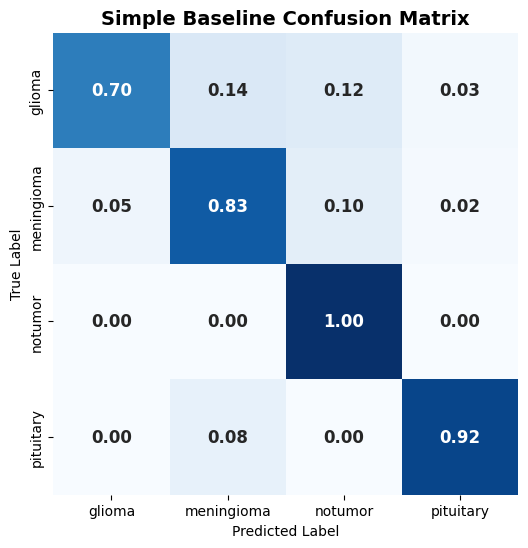

Saved: /content/drive/MyDrive/Brain Tumor Classification/confusion_matrices/Simple_Baseline.png

--- Evaluating VGG16 (Stage 2) ---
Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 652s 13s/step


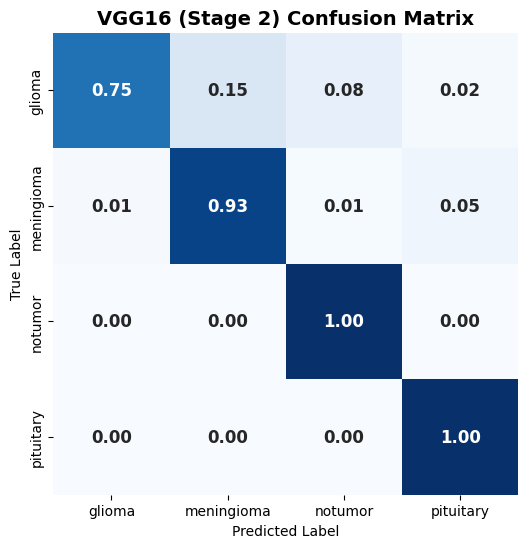

Saved: /content/drive/MyDrive/Brain Tumor Classification/confusion_matrices/VGG16_Stage_2.png

--- Evaluating ResNet50 (Stage 2) ---
Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 197s 4s/step


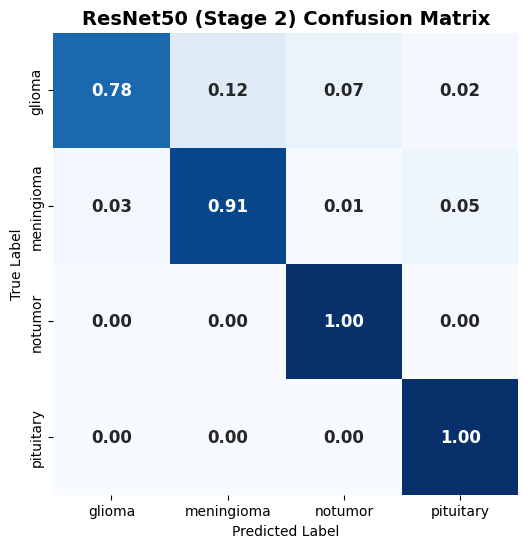

Saved: /content/drive/MyDrive/Brain Tumor Classification/confusion_matrices/ResNet50_Stage_2.png

--- Evaluating EfficientNetB0 (Stage 1) ---
Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step


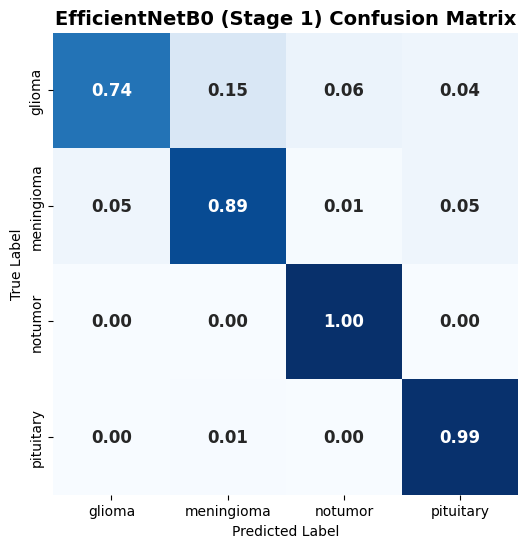

Saved: /content/drive/MyDrive/Brain Tumor Classification/confusion_matrices/EfficientNetB0_Stage_1.png


In [5]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

BASE_PATH = "/content/drive/MyDrive/Brain Tumor Classification"

MODELS_PATH = os.path.join(BASE_PATH, 'models')
TEST_DATA_PATH = os.path.join(BASE_PATH, "dataset", "Testing")

CM_SAVE_PATH = os.path.join(BASE_PATH, "confusion_matrices")
os.makedirs(CM_SAVE_PATH, exist_ok=True)

MODEL_FILES = {
    'Simple Baseline': 'baseline_model.keras',
    'VGG16 (Stage 2)': 'vgg16_finetuned.keras',
    'ResNet50 (Stage 2)': 'resnet50_finetuned.keras',
    'EfficientNetB0 (Stage 1)': 'effnet_stage1.keras'
}

results_dict = {}

for name, filename in MODEL_FILES.items():
    model_path = os.path.join(MODELS_PATH, filename)
    print(f"\n--- Evaluating {name} ---")

    if not os.path.exists(model_path):
        print(f"Skipping {name}: File not found.")
        continue

    model = load_model(model_path)


    if "ResNet" in name:
        test_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)
    elif "EfficientNet" in name:
        test_datagen = ImageDataGenerator(preprocessing_function=eff_preprocess)
    else:
        test_datagen = ImageDataGenerator(rescale=1./255)

    # recreate generator (IMPORTANT)
    test_gen = test_datagen.flow_from_directory(
        TEST_DATA_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    CLASS_NAMES = list(test_gen.class_indices.keys())
    y_true = test_gen.classes

    test_gen.reset()

    y_pred_probs = model.predict(
        test_gen,
        steps=len(test_gen),
        verbose=1
    )

    y_pred = np.argmax(y_pred_probs, axis=1)
    y_pred = y_pred[:len(y_true)]

    # Metrics
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    results_dict[name] = report

    # Normalize
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 6))

    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        cbar=False,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        annot_kws={"size": 12, "weight": "bold"}
    )

    plt.title(f'{name} Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    filename_safe = name.replace(" ", "_").replace("(", "").replace(")", "")
    save_path = os.path.join(CM_SAVE_PATH, f"{filename_safe}.png")

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"Saved: {save_path}")

    del model
    tf.keras.backend.clear_session()

## Classification Reports


--- Evaluating Simple Baseline ---
Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 712ms/step
              precision    recall  f1-score   support

      glioma       0.93      0.70      0.80       400
  meningioma       0.79      0.83      0.81       400
     notumor       0.81      1.00      0.90       400
   pituitary       0.96      0.92      0.94       400

    accuracy                           0.86      1600
   macro avg       0.87      0.86      0.86      1600
weighted avg       0.87      0.86      0.86      1600



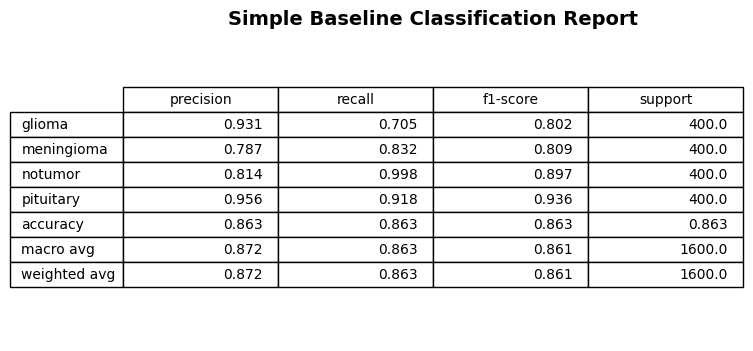

Saved: /content/drive/MyDrive/Brain Tumor Classification/classification_reports/Simple_Baseline_report.png

--- Evaluating VGG16 (Stage 2) ---
Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 644s 13s/step
              precision    recall  f1-score   support

      glioma       0.98      0.75      0.85       400
  meningioma       0.86      0.93      0.89       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.94      1.00      0.97       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



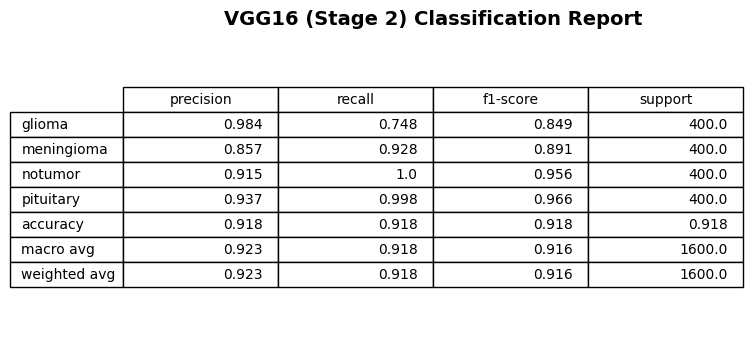

Saved: /content/drive/MyDrive/Brain Tumor Classification/classification_reports/VGG16_Stage_2_report.png

--- Evaluating ResNet50 (Stage 2) ---
Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 206s 4s/step
              precision    recall  f1-score   support

      glioma       0.96      0.78      0.86       400
  meningioma       0.88      0.91      0.89       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.93      1.00      0.96       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



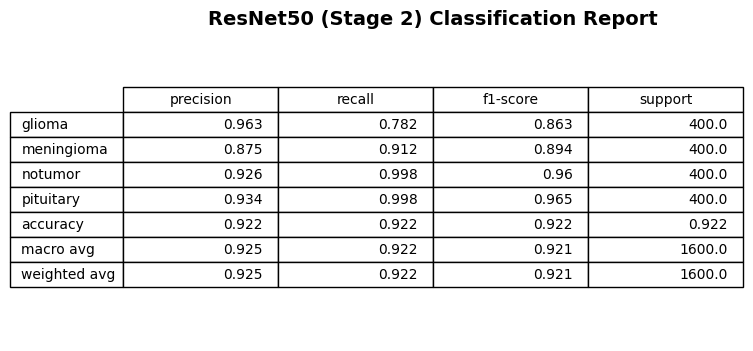

Saved: /content/drive/MyDrive/Brain Tumor Classification/classification_reports/ResNet50_Stage_2_report.png

--- Evaluating EfficientNetB0 (Stage 1) ---
Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step
              precision    recall  f1-score   support

      glioma       0.93      0.74      0.83       400
  meningioma       0.85      0.89      0.87       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.91      0.99      0.95       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.90      1600
weighted avg       0.91      0.91      0.90      1600



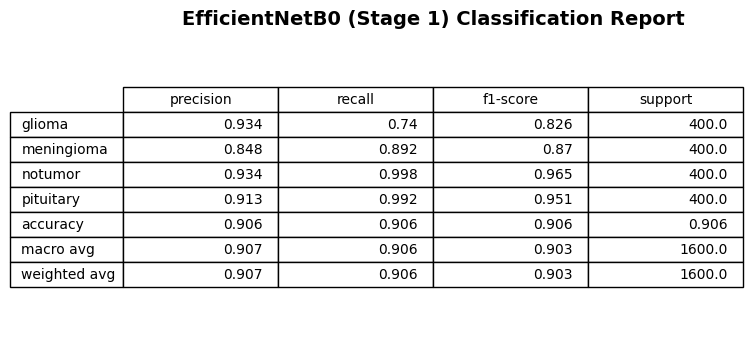

Saved: /content/drive/MyDrive/Brain Tumor Classification/classification_reports/EfficientNetB0_Stage_1_report.png


In [6]:

BASE_PATH = "/content/drive/MyDrive/Brain Tumor Classification"

MODELS_PATH = os.path.join(BASE_PATH, 'models')
TEST_DATA_PATH = os.path.join(BASE_PATH, "dataset", "Testing")

REPORT_SAVE_PATH = os.path.join(BASE_PATH, "classification_reports")
os.makedirs(REPORT_SAVE_PATH, exist_ok=True)


MODEL_FILES = {
    'Simple Baseline': 'baseline_model.keras',
    'VGG16 (Stage 2)': 'vgg16_finetuned.keras',
    'ResNet50 (Stage 2)': 'resnet50_finetuned.keras',
    'EfficientNetB0 (Stage 1)': 'effnet_stage1.keras'
}


for name, filename in MODEL_FILES.items():
    print(f"\n--- Evaluating {name} ---")

    model_path = os.path.join(MODELS_PATH, filename)

    if not os.path.exists(model_path):
        print(f"Skipping {name}: File not found.")
        continue

    model = load_model(model_path)

    if "ResNet" in name:
        test_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)
    elif "EfficientNet" in name:
        test_datagen = ImageDataGenerator(preprocessing_function=eff_preprocess)
    else:
        test_datagen = ImageDataGenerator(rescale=1./255)

    test_gen = test_datagen.flow_from_directory(
        TEST_DATA_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    CLASS_NAMES = list(test_gen.class_indices.keys())
    y_true = test_gen.classes

    test_gen.reset()

    # Predict
    y_pred_probs = model.predict(test_gen, steps=len(test_gen), verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_pred = y_pred[:len(y_true)]


    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )

    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # Convert to DataFrame
    report_df = pd.DataFrame(report_dict).transpose().round(3)


    plt.figure(figsize=(8, 4))
    plt.axis('off')

    table = plt.table(
        cellText=report_df.values,
        colLabels=report_df.columns,
        rowLabels=report_df.index,
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    plt.title(f'{name} Classification Report', fontsize=14, fontweight='bold')


    filename_safe = name.replace(" ", "_").replace("(", "").replace(")", "")
    save_path = os.path.join(REPORT_SAVE_PATH, f"{filename_safe}_report.png")

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"Saved: {save_path}")


    del model
    tf.keras.backend.clear_session()

##  Final Model Comparison & Key Insights

| Model | Best Configuration | Test Accuracy | Macro F1-Score | Inference Speed |
|------|-------------------|--------------|----------------|----------------|
| Simple CNN (Baseline) | Baseline | 86% | 0.86 | Moderate |
| VGG16 | Stage 2 (Fine-tuned) | 92% | 0.92 | Slow |
| ResNet50 | Stage 2 (Fine-tuned) | 92% | 0.92 | Balanced |
| EfficientNetB0 | Stage 1 (Frozen) | 91% | 0.90 | Highly Efficient |
---

### Best Performing Model

ResNet50 (Stage 2) and VGG16 (Stage 2) achieved the highest overall performance (~92% test accuracy).  
While both models provide similar accuracy, **ResNet50 is the more practical choice** due to its significantly lower parameter count and better inference efficiency.

---

###  Hardest Class to Classify: Glioma

Across all models, **glioma** was the most challenging class:

- Recall ≈ 0.70 – 0.78  
- Higher misclassification compared to other classes  

This indicates:

- High intra-class variability  
- Overlapping visual features with other tumor types  

In contrast, **notumor** achieved near-perfect recall (~1.00), showing that models reliably distinguish healthy brain scans.

---

###  EfficientNetB0:

EfficientNetB0 achieved its highest validation accuracy of **94.46% during Stage 1**.  
However, performance slightly decreased during Stage 2 fine-tuning (~91–93%).

This behavior can be explained by:

- Highly optimized pretrained features in Stage 1  
- Feature distribution shifts during fine-tuning  
- Sensitivity of **Batch Normalization** layers  
- Impact of **Squeeze-and-Excitation (SE) blocks** on global feature recalibration  

This demonstrates **diminishing returns from fine-tuning** for compound-scaled architectures on relatively smaller datasets.

---

### Overall Conclusion

- Transfer learning improved performance by ~6% over the baseline CNN  
- Fine-tuning significantly benefited VGG16 and ResNet50  
- EfficientNetB0 performed best as a feature extractor (Stage 1)  
- Model performance varies across classes, with glioma being the most difficult  

 For this dataset, **ResNet50 provides the best balance between accuracy, stability, and computational efficiency**, making it the most suitable model for deployment.

---

### Experimental Consistency

All models were trained and evaluated under identical conditions to ensure a **fair and unbiased comparison**.